In [2]:
from datetime import datetime
import fsspec
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import multiprocessing
import numpy as np
import xarray as xr

In [3]:
def load_files(lookup: str) -> xr.Dataset:
    local = fsspec.filesystem('file')
    files = local.glob(lookup)
    with multiprocessing.Pool() as pool:
        ds_list = pool.map(xr.open_dataset, files)
    try:
        ds = xr.combine_by_coords(ds_list, combine_attrs='drop_conflicts')
    except:
        ds = xr.concat(ds_list, dim='time', combine_attrs='drop_conflicts')
        ds = ds.drop_duplicates(dim='time')
    ds = ds.sortby('time')
    return ds

In [5]:
main_sbe38 = load_files('C:/Users/annar/Box/pco2_skq/data/daily/*FLOWTHROUGH_CTBD_SBE38*/*FLOWTHROUGH_CTBD_SBE38*.nc')
main_sbe38 = main_sbe38.sel(time=slice(datetime(2024, 10, 22, 12, 0, 0, 0), None))

#apollo = apollo[['air_temperature', 'apollo_sbe45_sea_water_temperature', 'apollo_sbe45_sea_water_practical_salinity',
#                 'barometric_pressure', 'fco2', 'pco2', 'sea_surface_temperature', 'sea_water_practical_salinity',
#                 'equilibrator_pco2', 'water_vapor_pressure', 'xco2_corr', 'li7815_h2o', 'li7815_xco2',
#                 'water_flow_rate']]

#apollo_sub = apollo.rolling({'time': 16}, center='True', min_periods=1).median(skipna=True)
#apollo_sub = apollo_sub.resample({'time': '15min'}).mean(skipna=True)

In [11]:
main_sbe45 = load_files('C:/Users/annar/Box/pco2_skq/data/daily/*MAIN-LAB_SBE45-1*/*MAIN*.nc')
main_sbe45 = main_sbe45.sel(time=slice(datetime(2024, 10, 22, 12, 0, 0, 0), None))

In [12]:
list(main_sbe45.keys())

['sea_water_electrical_conductivity',
 'sea_water_practical_salinity',
 'sea_water_temperature',
 'sensor_id',
 'speed_of_sound_in_sea_water']

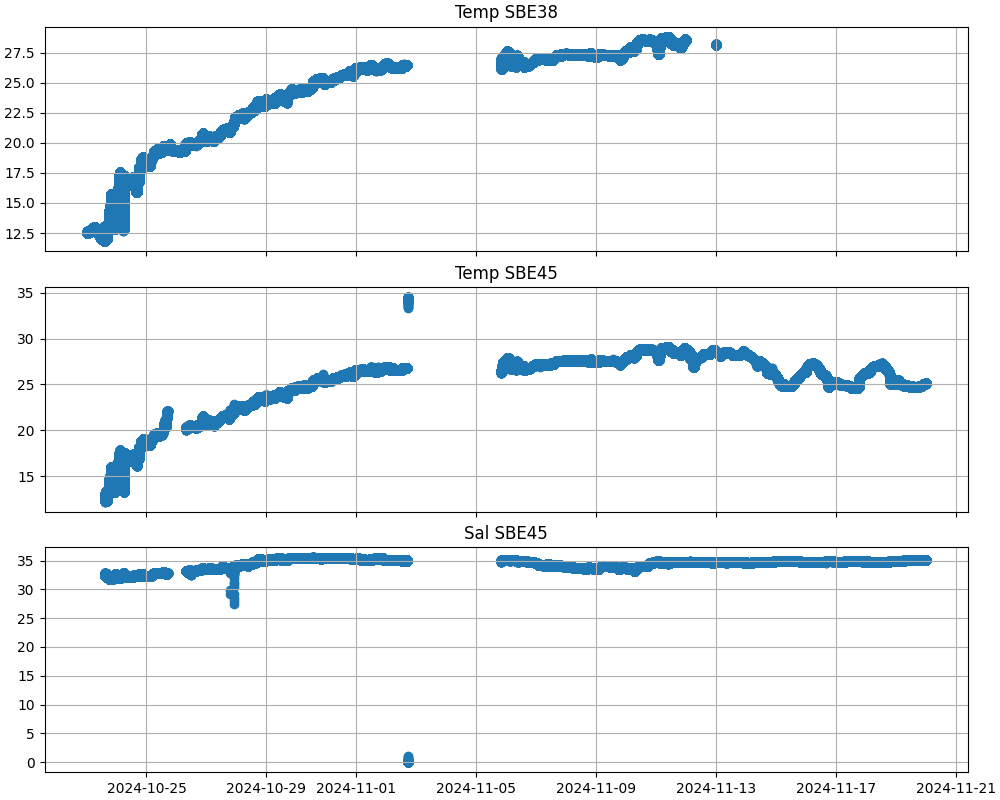

In [14]:
%matplotlib widget

fig, ax = plt.subplots(3,1, figsize = (10,8), constrained_layout = True, sharex=True)

ax[0].scatter(main_sbe38.time, main_sbe38.sea_water_temperature,label="vco2-pco2insitu")
ax[0].set_title('Temp SBE38')
ax[0].grid()

ax[1].scatter(main_sbe45.time, main_sbe45.sea_water_temperature,label="vco2-pco2insitu")
ax[1].set_title('Temp SBE45')
ax[1].grid()

ax[2].scatter(main_sbe45.time, main_sbe45.sea_water_practical_salinity, label="xco2_corr-eq_pco2")
ax[2].set_title('Sal SBE45')
ax[2].grid()

In [52]:
first = datetime(2024, 11, 2, 3, 5, 0, 0)
lastv = datetime(2024, 11, 2, 3, 6, 0, 0)

np.nanmean(main_sbe38.sea_water_temperature.sel(time=slice(first, lastv)), axis = 0)

np.nanmean(main_sbe45.sea_water_practical_salinity.sel(time=slice(first, lastv)), axis = 0)

35.10684166666667